## Resumen hallazgos

### 1. Variables continuas

**Reseñas (nulos como información):** Crear dummy `has_reviews` (1/0) e imputar nulos con -1 o 0.

**Sesgos por cola larga (Precios y Lluvia):** Aplicar transformación para comprimir las colas y normalizar la distribución.

---

### 2. Variables discretas

**Eventos (inflación de ceros):** El desbalance es extremo pero real.Dummy o colapso a ordinal (bajo, medio, alto)

**Minimum Nights:** Crear categorías, según estancia: corta(< 7 días), media (7-31 días), larga (31-62 días).

---

### 3. Variables categóricas

**Room Type:** Binarizar a `is_entire_home` (1 = Entire home/apt, 0 = resto).

**Festivos (is_holiday):** sin alterar a pesar de desbalanceo

---

### 4. Perfil temporal

**Sesgo del verano:** la construcción del modelo va a ser más robusta para temporada media-baja antes que alta por infrarrepresentación de meses de verano

### 5. Perfil espacial:

**Sesgo de barrio Eixample y alrededores:** el modelo puede verse influenciado por la referencia que supone este barrio y alrededores en su ajuste. 

# 0. Conexión con proyecto e importación de dataset

In [22]:
%load_ext autoreload
%autoreload 2

from cross_sectional import *

warnings.filterwarnings("ignore", module="statsmodels.tsa.stattools")
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df = gpd.read_parquet(r"D:\yannis_data\Descargas\airbnb_bcn_clean.parquet")

# 1. Variables continuas

In [3]:
continuas = ['listing_price', 'review_scores_rating', 'review_scores_cleanliness', 
            'review_scores_location', 'review_scores_value','temp_max', 'temp_min',
            'temp_mean', 'precipitation_mm']


 ESTADÍSTICOS DE SKEWNESS Y KURTOSIS)
                 Variable  Skewness  Kurtosis
            listing_price     18.45    461.79
         precipitation_mm      5.09     36.66
   review_scores_location     -4.92     39.23
     review_scores_rating     -3.95     24.01
review_scores_cleanliness     -3.81     22.75
      review_scores_value     -3.18     15.64
                temp_mean      0.68      0.01
                 temp_min      0.58     -0.36
                 temp_max      0.57      0.21
------------------------------------------------------------


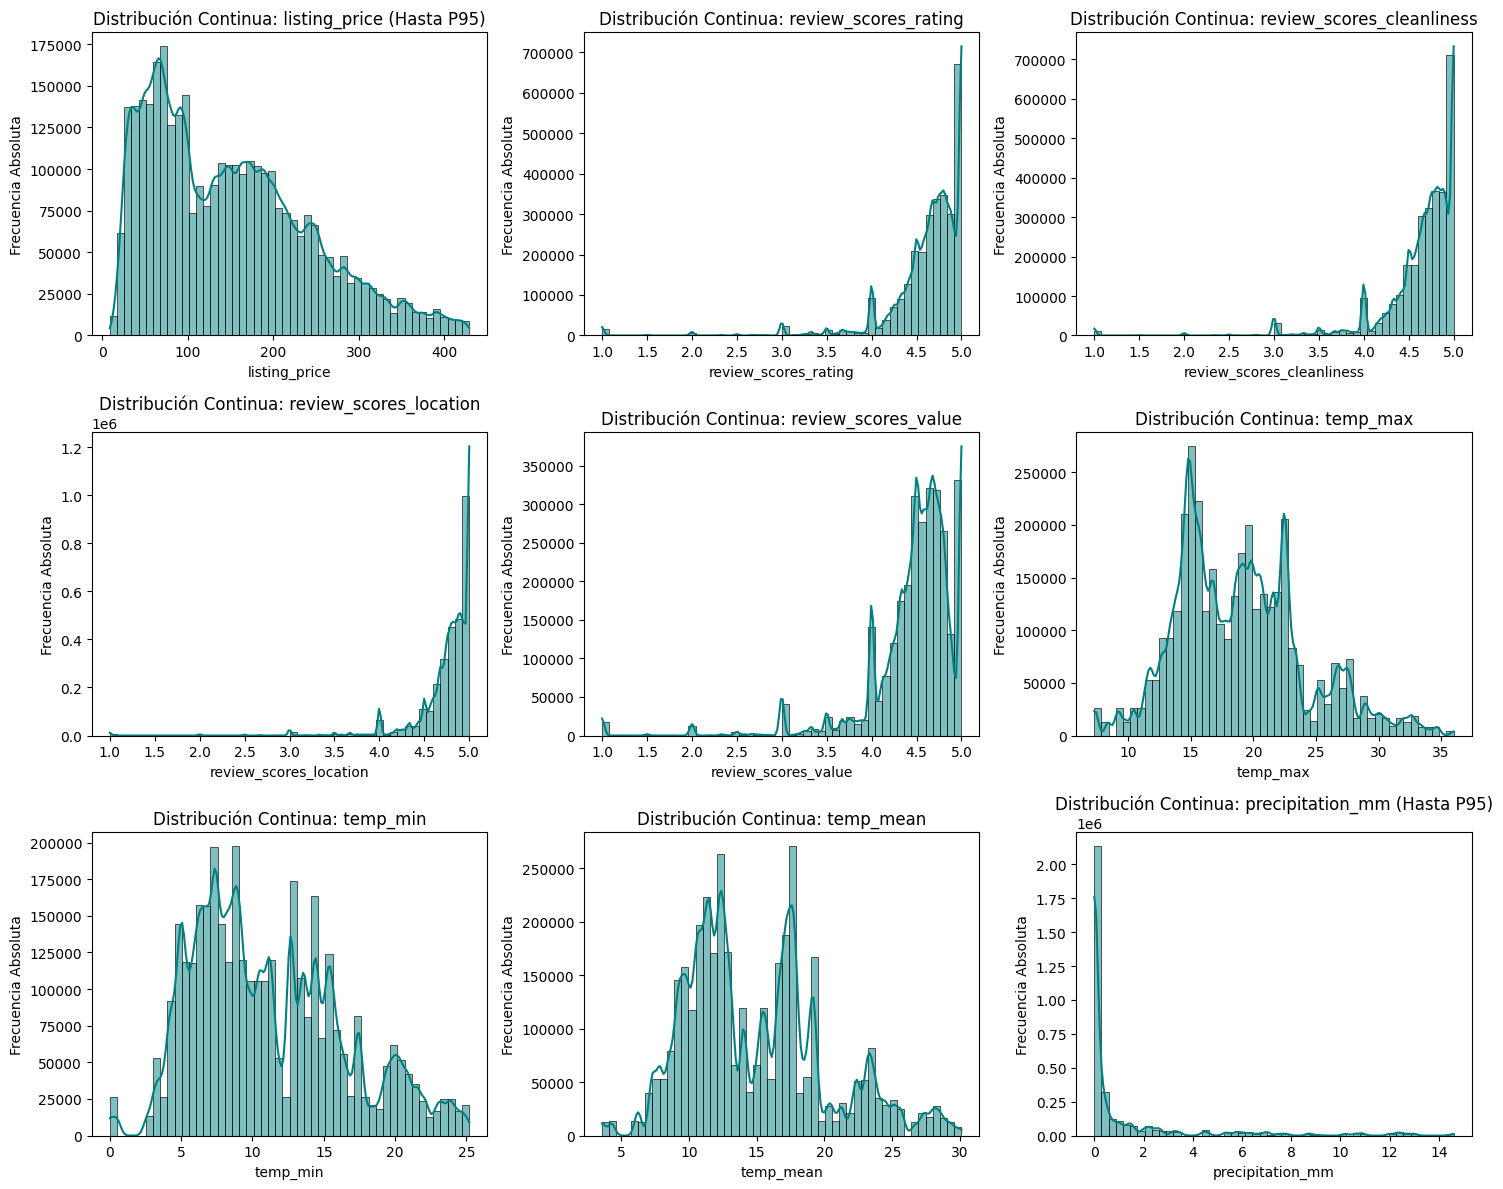

In [4]:
print_shape_statistics(df,continuas)
plot_continuous_distributions(df, continuas)

# 2. Variables discretas

In [11]:
discretas = ['accommodates', 'bedrooms', 'beds', 
            'minimum_nights',"num_events",
            'num_concerts', 'num_sports', 'num_festivals', 'max_attendance','total_attendance']
# days_to_next_holiday no aplica aqui
# number_of_reviews mucho ruido con bins predeterminadas


 ESTADÍSTICOS DE SKEWNESS Y KURTOSIS)
        Variable  Skewness  Kurtosis
      num_sports     12.43    169.22
total_attendance     11.19    146.82
   num_festivals     10.67    131.76
  max_attendance      9.11     94.35
    num_concerts      8.11     71.06
      num_events      6.13     40.51
  minimum_nights      4.51     59.55
            beds      2.90     18.67
        bedrooms      2.74     18.78
    accommodates      1.57      4.43
------------------------------------------------------------


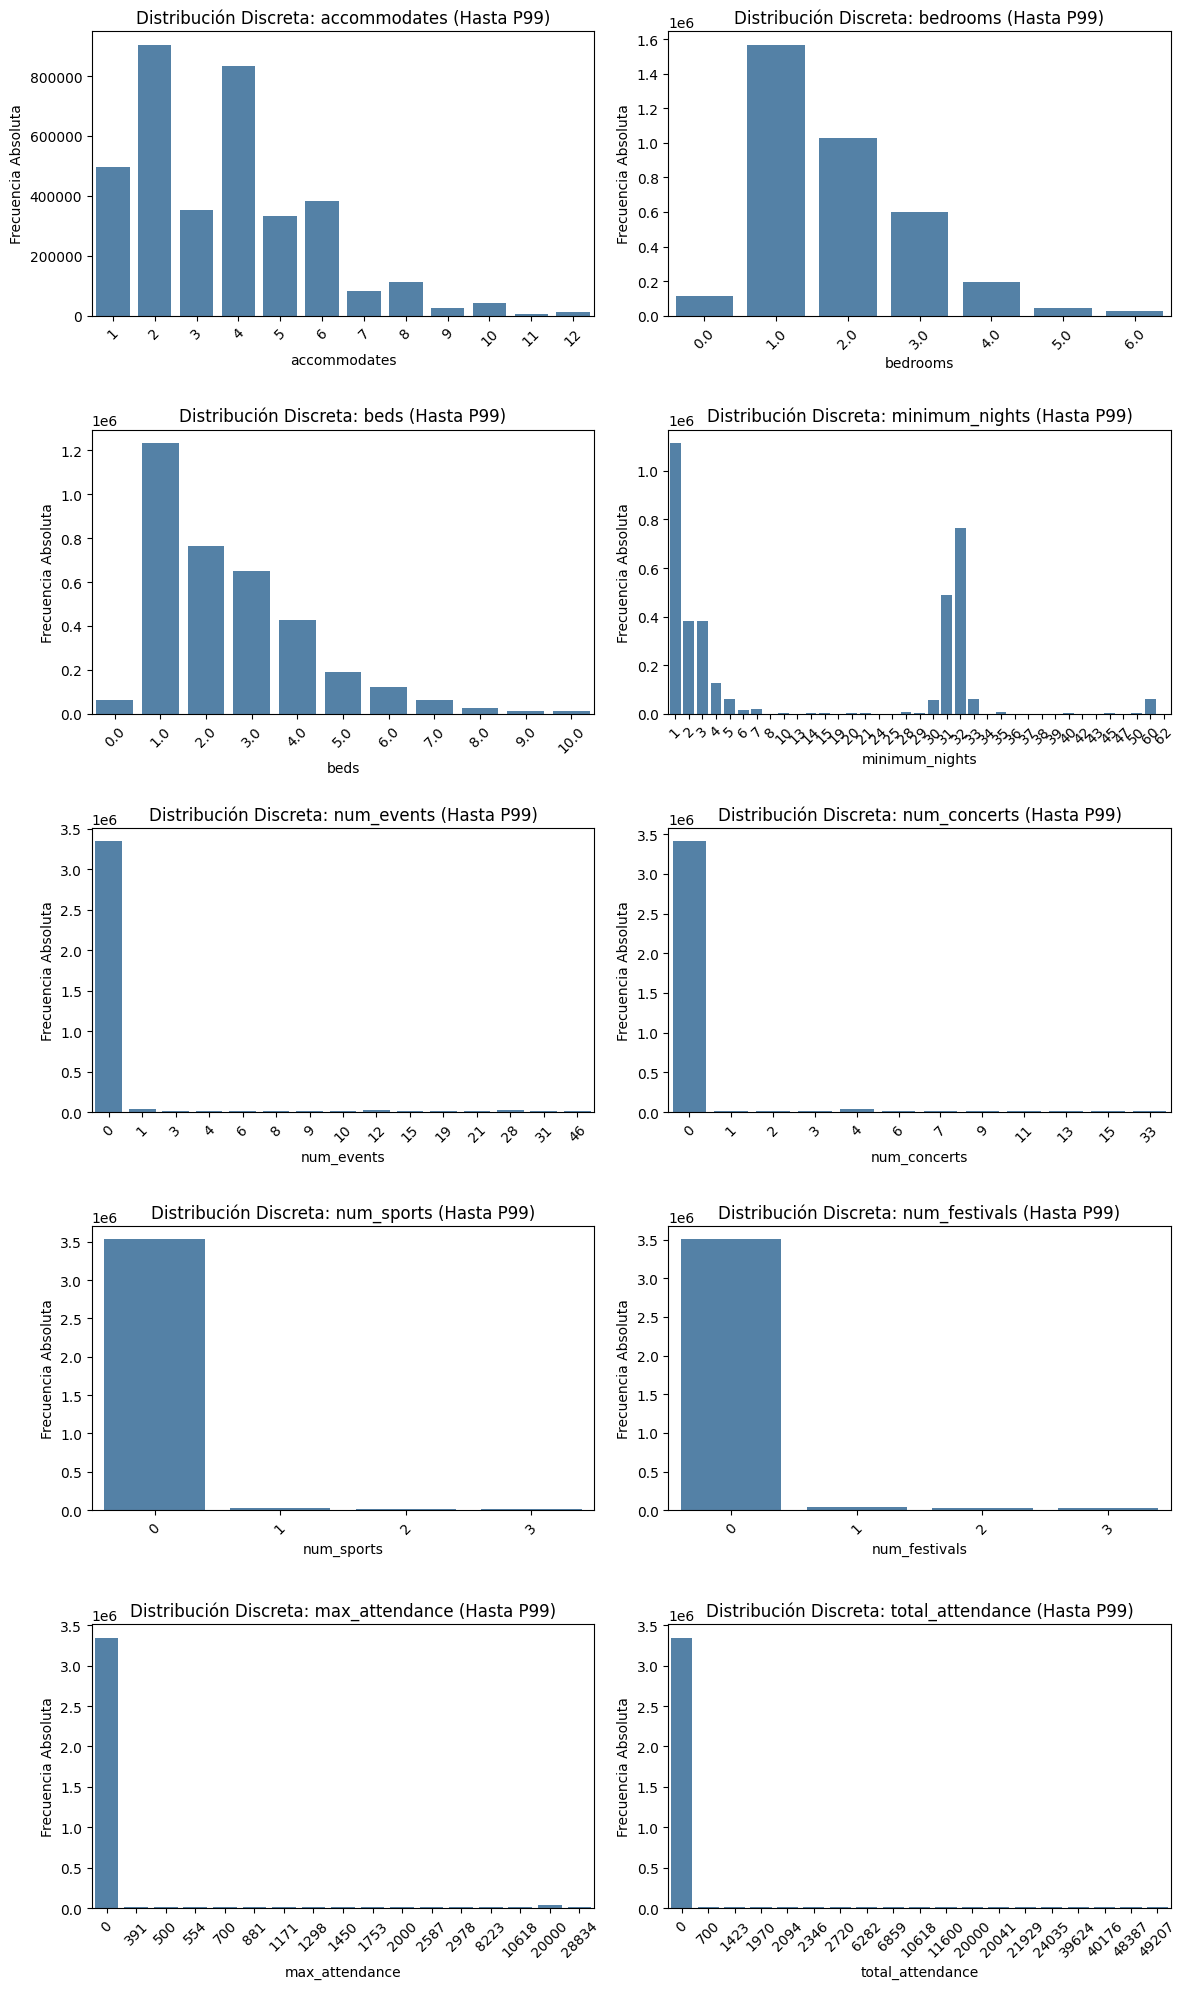

In [12]:
print_shape_statistics(df,discretas)  #se usa la misma que para continuas
plot_discrete_distributions(df, discretas)

# 3. Variables categóricas

In [7]:
categoricas = ['is_occupied', 'room_type', 'instant_bookable',"is_holiday"]
# categoría por barrio obviada porque se analizara en espacial

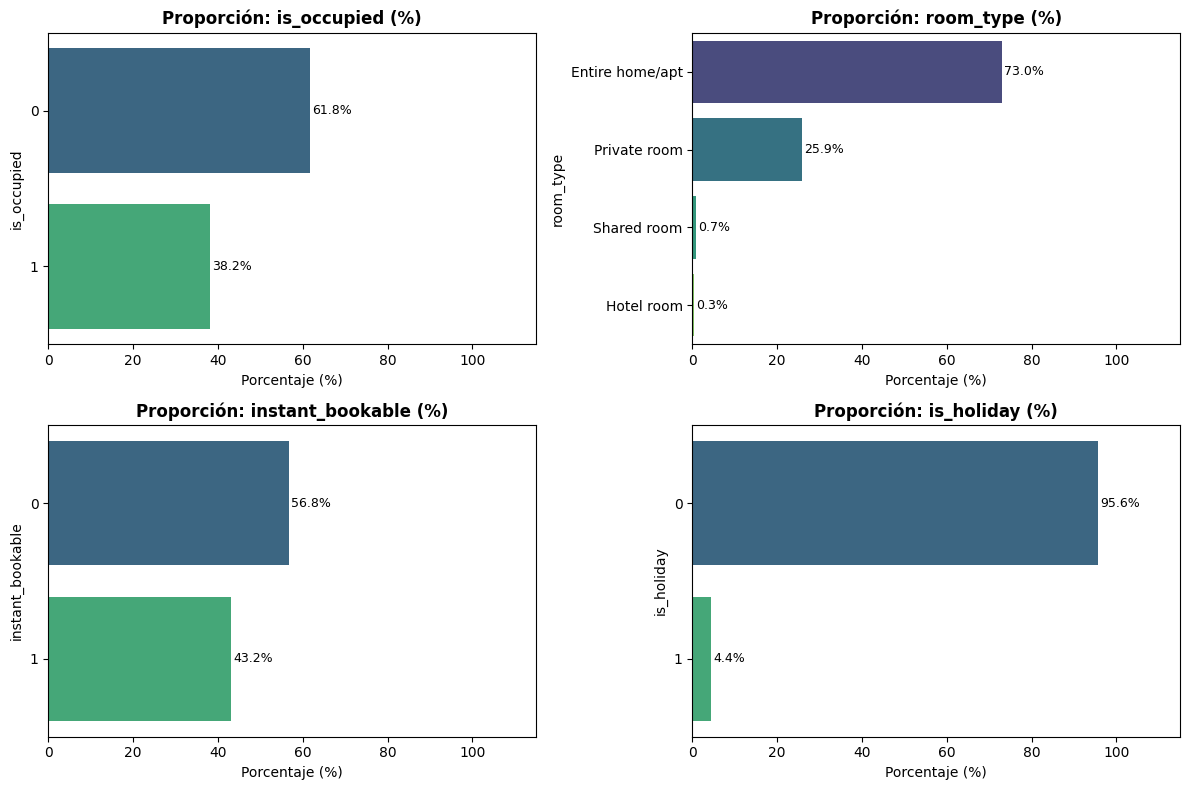

In [24]:
plot_categorical_proportions(df, categoricas)

## Análisis del perfil temporal

In [9]:
categoricas_temp = ['day_of_week', 'month', 'year', 'is_weekend']

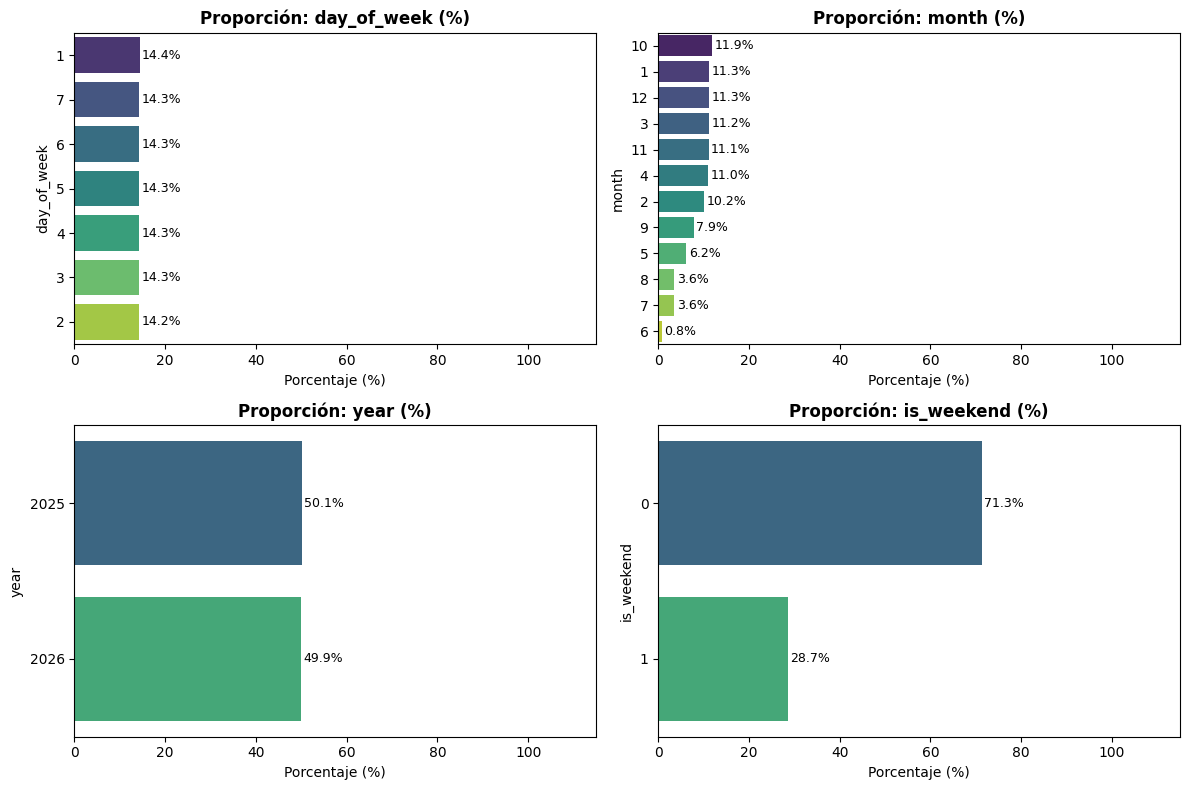

In [23]:
plot_categorical_proportions(df, categoricas_temp)

## Análisis del perfil espacial

In [15]:
categoricas_space = ['neighbourhood_cleansed']

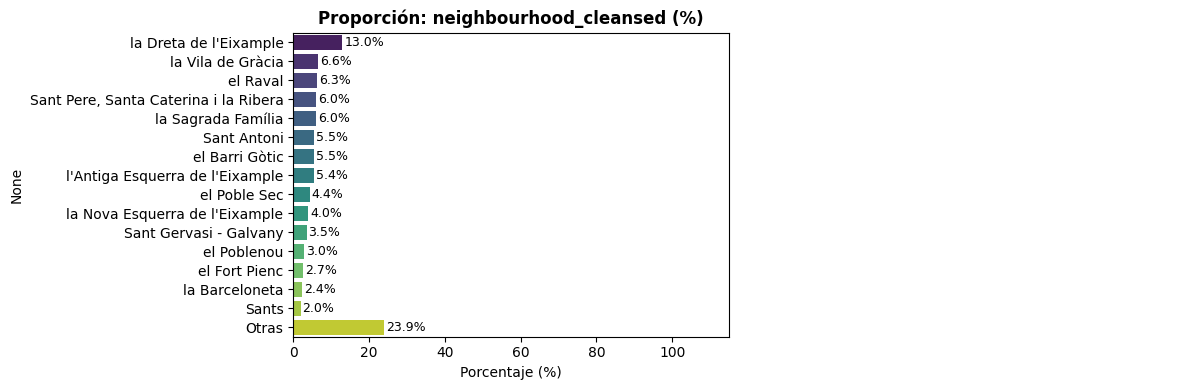

In [25]:
plot_categorical_proportions(df, categoricas_space)